In [1]:
import pickle, copy, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib as mpl
import matplotlib.cm as cm
import scipy.stats as sps
from random import shuffle
import itertools

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
#import la_forge.utils as lf_utils
#lf_utils.set_publication_params({'text.usetex':False})
#fig_dir = '/home/baierj/projects/hasasia2/hasasia2_paper/figures'

In [2]:
import healpy as hp
import astropy.units as u
import astropy.constants as c
from astropy.coordinates import SkyCoord
#import plot #Script originally written by Leo Stein for making pretty sky maps. 

# Setting various healpy quantities and GW source sky positions.
NSIDE = 8
NPIX = hp.nside2npix(NSIDE)
IPIX = np.arange(NPIX)
theta_gw, phi_gw = hp.pix2ang(nside=NSIDE,ipix=IPIX)

In [3]:
import numpy as np
import scipy.linalg as sl
import matplotlib.pyplot as plt
%matplotlib inline
import glob, pickle, json
import hasasia.sensitivity as hsen
import hasasia.sim as hsim
import hasasia.skymap as hsky
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['figure.figsize'] = [5,3]
mpl.rcParams['text.usetex'] = True
from enterprise.pulsar import Pulsar as ePulsar
ng20_irn = '/Users/ashokan/osu/sarahspta/NG20_irn/'
pardir = ng20_irn
timdir = ng20_irn
pars = sorted(glob.glob(pardir+'*.par'))
tims = sorted(glob.glob(timdir+'*.tim'))

/opt/homebrew/Caskroom/mambaforge/base/envs/sarahspta/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename
libstempo not installed. PINT or libstempo are required to use par and tim files.


In [4]:
pars[0]

'/Users/ashokan/osu/sarahspta/NG20_irn/B1855+09.par'

In [5]:
tims[0]

'/Users/ashokan/osu/sarahspta/NG20_irn/B1855+09.tim'

In [6]:
ePsrs = []
for par,tim in zip(pars,tims):
    ePsr = ePulsar(par, tim,  ephem='DE440')
    ePsrs.append(ePsr)
    print('\rPSR {0} complete'.format(ePsr.name),end='',flush=True)

2025-10-02 20:58:26.455 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2025-10-02 20:58:26.664 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-10-02 20:58:26.668 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-10-02 20:58:26.678 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-02 20:58:26.678 | DEBUG    | pint.observatory:_load_gps_clock:108 - Loading global GPS clock file
2025-10-02 20:58:26.719 | DEBUG    | pint.observatory.clock_file:__init__:812 - Global clock file gps2utc.clk saving kwargs={'bogus_last_correction': False, 'valid_beyond_ends': False}
2025-10-02 20:58:26.741 | DEBUG    | pint.observatory.clock_file:read_tempo2_clock_file:463 - Loading TEMPO2-format observatory clock correction file gps2utc.clk (/Users/ashokan/.astropy/cache/download/url/d3c81b5766f4bfb84e65504c8a453085/conten

PSR B1855+09 complete

2025-10-02 20:58:28.867 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2025-10-02 20:58:29.004 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-10-02 20:58:29.006 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-10-02 20:58:29.012 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-02 20:58:29.013 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock correction (~27 us)
2025-10-02 20:58:29.014 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-10-02 20:58:29.048 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-02 20:58:29.049 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock co

PSR B1953+29 complete

2025-10-02 20:58:30.179 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2025-10-02 20:58:30.295 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-10-02 20:58:30.298 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-10-02 20:58:30.303 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-02 20:58:30.304 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock correction (~27 us)
2025-10-02 20:58:30.304 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-10-02 20:58:30.347 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-02 20:58:30.349 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock co

...

PSR J2302+4442 complete

2025-10-02 20:59:54.112 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2025-10-02 20:59:54.262 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-10-02 20:59:54.265 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-10-02 20:59:54.280 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-02 20:59:54.281 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock correction (~27 us)
2025-10-02 20:59:54.282 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-10-02 20:59:54.375 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-02 20:59:54.376 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock co

PSR J2317+1439 complete

2025-10-02 20:59:55.598 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2025-10-02 20:59:55.658 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-10-02 20:59:55.660 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-10-02 20:59:55.663 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-02 20:59:55.664 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock correction (~27 us)
2025-10-02 20:59:55.665 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-10-02 20:59:55.694 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-02 20:59:55.695 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock co

PSR J2322+2057 complete

In [7]:
len(ePsrs)

77

In [8]:
def make_corr(psr,noise):
    N = psr.toaerrs.size
    corr = np.zeros((N,N))
    _, _, fl, _, bi = hsen.quantize_fast(psr.toas,psr.toaerrs,
                                         flags=psr.flags['f'],dt=1)
    keys = [ky for ky in noise.keys() if psr.name in ky]
    backends = np.unique(psr.flags['f'])
    sigma_sqr = np.zeros(N)
    ecorrs = np.zeros_like(fl,dtype=float)
    for be in backends:
        mask = np.where(psr.flags['f']==be)
        key_ef = '{0}_{1}_{2}'.format(psr.name,be,'efac')
        key_eq = '{0}_{1}_log10_{2}'.format(psr.name,be,'equad')
        sigma_sqr[mask] = (noise[key_ef]**2 * ((psr.toaerrs[mask]**2)
                           + (10**noise[key_eq])**2))
        mask_ec = np.where(fl==be)
        key_ec = '{0}_{1}_log10_{2}'.format(psr.name,be,'ecorr')
        ecorrs[mask_ec] = np.ones_like(mask_ec) * (10**noise[key_ec])
    j = [ecorrs[ii]**2*np.ones((len(bucket),len(bucket)))
         for ii, bucket in enumerate(bi)]

    J = sl.block_diag(*j)
    corr = np.diag(sigma_sqr) + J
    return corr

In [9]:
def make_corr_our(psr):
    sigma_sqrt = psr.toaerrs**2
    corr = np.diag(sigma_sqrt)
    return corr


In [10]:
noise_dir = '/Users/ashokan/osu/sarahspta/'#20yr_noisedict_rn+curn-bpl/'
noise_files = '/Users/ashokan/osu/sarahspta/20yr_noisedict_rn+curn-bpl.json'
noise_files

'/Users/ashokan/osu/sarahspta/20yr_noisedict_rn+curn-bpl.json'

In [11]:
import json
with open(noise_files,'r') as f:
    noise = json.load(f)

In [12]:
rn_psrs = noise
print(rn_psrs)

{'B1855+09_red_noise_gamma': 4.131720100411879, 'B1855+09_red_noise_log10_A': -14.283134228701593, 'B1937+21_red_noise_gamma': 2.372077003631106, 'B1937+21_red_noise_log10_A': -12.779210971140605, 'B1953+29_red_noise_gamma': 2.246346131593814, 'B1953+29_red_noise_log10_A': -12.774023346685262, 'J0023+0923_red_noise_gamma': 0.1992954711011312, 'J0023+0923_red_noise_log10_A': -12.49852143026507, 'J0030+0451_red_noise_gamma': 5.220711432902525, 'J0030+0451_red_noise_log10_A': -14.823656247523614, 'J0102+4839_red_noise_gamma': 2.8136105227140513, 'J0102+4839_red_noise_log10_A': -12.274238594589225, 'J0125-2327_red_noise_gamma': 1.362665710133176, 'J0125-2327_red_noise_log10_A': -17.523352111518513, 'J0154+1833_red_noise_gamma': 0.2014365329849749, 'J0154+1833_red_noise_log10_A': -15.416251404217899, 'J0218+4232_red_noise_gamma': 0.5462921162310412, 'J0218+4232_red_noise_log10_A': -11.570982211465163, 'J0340+4130_red_noise_gamma': 0.2721532889980398, 'J0340+4130_red_noise_log10_A': -12.8066

In [13]:
nihans_dict = '/Users/ashokan/osu/sarahspta/15yr_v1_fl_fwn_dict.json'
with open(nihans_dict,'r') as f:
    nihans_noise = json.load(f)

In [14]:
nihans_noise

{'B1855+09_430_ASP_efac': 1.0952941083653116,
 'B1855+09_430_ASP_log10_ecorr': -8.491311799818622,
 'B1855+09_430_ASP_log10_equad': -6.830689524145644,
 'B1855+09_430_PUPPI_efac': 0.9993695969853792,
 'B1855+09_430_PUPPI_log10_ecorr': -5.72243053442663,
 'B1855+09_430_PUPPI_log10_equad': -6.402031561742483,
 'B1855+09_L-wide_ASP_efac': 1.0244127763116193,
 'B1855+09_L-wide_ASP_log10_ecorr': -6.097057879717841,
 'B1855+09_L-wide_ASP_log10_equad': -6.481015807255515,
 'B1855+09_L-wide_PUPPI_efac': 1.1004705572093467,
 'B1855+09_L-wide_PUPPI_log10_ecorr': -6.643946570100447,
 'B1855+09_L-wide_PUPPI_log10_equad': -7.266611429595852,
 'B1855+09_red_noise_gamma': 3.6128353448907142,
 'B1855+09_red_noise_log10_A': -13.902575986007228,
 'B1937+21_L-wide_ASP_efac': 2.20289447487106,
 'B1937+21_L-wide_ASP_log10_ecorr': -6.923818483058105,
 'B1937+21_L-wide_ASP_log10_equad': -6.823019703076379,
 'B1937+21_L-wide_PUPPI_efac': 1.5528476452175854,
 'B1937+21_L-wide_PUPPI_log10_ecorr': -6.92713616913

In [15]:
Tspan = hsen.get_Tspan(ePsrs)
fyr = 1/(365.25*24*3600)
freqs = np.logspace(np.log10(1/(5*Tspan)),np.log10(2e-7),600)

In [16]:
Tspan/(365*86400)

np.longdouble('20.634273326866975')

In [17]:
ng20_noise_dict = '/Users/ashokan/osu/sarahspta/ng20_v1p1_dmx_noise_dict.json'
#from https://drive.google.com/drive/folders/1GQXnpyRglqPHwgQs6vE8VK-6VoL9WbSj
with open(ng20_noise_dict,'r') as f:
    ng20_noise_real = json.load(f)

In [18]:
ng20_noise_real

{'B1855+09_430_ASP_efac': 1.158963728839342,
 'B1855+09_430_ASP_log10_ecorr': -7.454005000831911,
 'B1855+09_430_ASP_log10_t2equad': -7.465514539957289,
 'B1855+09_430_PUPPI_efac': 1.0191752429233873,
 'B1855+09_430_PUPPI_log10_ecorr': -6.19762265347091,
 'B1855+09_430_PUPPI_log10_t2equad': -6.68557139992855,
 'B1855+09_CHIME_efac': 0.9576629507758594,
 'B1855+09_CHIME_log10_ecorr': -7.485146600960501,
 'B1855+09_CHIME_log10_t2equad': -7.277761761501743,
 'B1855+09_L-wide_ASP_efac': 1.173089201118123,
 'B1855+09_L-wide_ASP_log10_ecorr': -6.110205636255204,
 'B1855+09_L-wide_ASP_log10_t2equad': -6.5905557986246235,
 'B1855+09_L-wide_PUPPI_efac': 1.2843581837455045,
 'B1855+09_L-wide_PUPPI_log10_ecorr': -6.465263275548019,
 'B1855+09_L-wide_PUPPI_log10_t2equad': -8.13403683681612,
 'B1855+09_Rcvr1_2_VEGAS_efac': 1.0491085140124021,
 'B1855+09_Rcvr1_2_VEGAS_log10_ecorr': -7.170487732418092,
 'B1855+09_Rcvr1_2_VEGAS_log10_t2equad': -7.322750828740293,
 'B1855+09_red_noise_gamma': 3.4126912

In [104]:
chime_vegas_noise_dict = {}

for k, v in ng20_noise_real.items():
    new_key = k.replace("t2equad", "equad")
    if "CHIME" in k or "YUPPI" in k or "VEGAS" in k or "J0125-2327" in k or "J0154+1833" in k or "J0614-3329" in k or "J0621+2514" in k or "J0732+2314" in k or "J0751+1807" in k or "J1022+1001" in k or "J1803+1358" in k or "J2022+2534" in k or "J2039-3616" in k or "J2150-0326" in k:
        print(k)
        chime_vegas_noise_dict[new_key] = v


B1855+09_CHIME_efac
B1855+09_CHIME_log10_ecorr
B1855+09_CHIME_log10_t2equad
B1855+09_Rcvr1_2_VEGAS_efac
B1855+09_Rcvr1_2_VEGAS_log10_ecorr
B1855+09_Rcvr1_2_VEGAS_log10_t2equad
B1937+21_3GHz_YUPPI_efac
B1937+21_3GHz_YUPPI_log10_ecorr
B1937+21_3GHz_YUPPI_log10_t2equad
B1937+21_CHIME_efac
B1937+21_CHIME_log10_ecorr
B1937+21_CHIME_log10_t2equad
B1937+21_Rcvr1_2_VEGAS_efac
B1937+21_Rcvr1_2_VEGAS_log10_ecorr
B1937+21_Rcvr1_2_VEGAS_log10_t2equad
B1937+21_Rcvr_800_VEGAS_efac
B1937+21_Rcvr_800_VEGAS_log10_ecorr
B1937+21_Rcvr_800_VEGAS_log10_t2equad
B1953+29_CHIME_efac
B1953+29_CHIME_log10_ecorr
B1953+29_CHIME_log10_t2equad
J0023+0923_CHIME_efac
J0023+0923_CHIME_log10_ecorr
J0023+0923_CHIME_log10_t2equad
J0023+0923_Rcvr1_2_VEGAS_efac
J0023+0923_Rcvr1_2_VEGAS_log10_ecorr
J0023+0923_Rcvr1_2_VEGAS_log10_t2equad
J0030+0451_CHIME_efac
J0030+0451_CHIME_log10_ecorr
J0030+0451_CHIME_log10_t2equad
J0030+0451_Rcvr1_2_VEGAS_efac
J0030+0451_Rcvr1_2_VEGAS_log10_ecorr
J0030+0451_Rcvr1_2_VEGAS_log10_t2equad
J0

In [105]:
len(chime_vegas_noise_dict)

616

In [106]:
nihans_noise.update(chime_vegas_noise_dict)

In [107]:
len(nihans_noise)

1542

In [108]:
nihans_noise

{'B1855+09_430_ASP_efac': 1.0952941083653116,
 'B1855+09_430_ASP_log10_ecorr': -8.491311799818622,
 'B1855+09_430_ASP_log10_equad': -6.830689524145644,
 'B1855+09_430_PUPPI_efac': 0.9993695969853792,
 'B1855+09_430_PUPPI_log10_ecorr': -5.72243053442663,
 'B1855+09_430_PUPPI_log10_equad': -6.402031561742483,
 'B1855+09_L-wide_ASP_efac': 1.0244127763116193,
 'B1855+09_L-wide_ASP_log10_ecorr': -6.097057879717841,
 'B1855+09_L-wide_ASP_log10_equad': -6.481015807255515,
 'B1855+09_L-wide_PUPPI_efac': 1.1004705572093467,
 'B1855+09_L-wide_PUPPI_log10_ecorr': -6.643946570100447,
 'B1855+09_L-wide_PUPPI_log10_equad': -7.266611429595852,
 'B1855+09_red_noise_gamma': 3.6128353448907142,
 'B1855+09_red_noise_log10_A': -13.902575986007228,
 'B1937+21_L-wide_ASP_efac': 2.20289447487106,
 'B1937+21_L-wide_ASP_log10_ecorr': -6.923818483058105,
 'B1937+21_L-wide_ASP_log10_equad': -6.823019703076379,
 'B1937+21_L-wide_PUPPI_efac': 1.5528476452175854,
 'B1937+21_L-wide_PUPPI_log10_ecorr': -6.92713616913

In [109]:
A_gwb, gamma_gwb = 6.4e-15, 3.2 # median values from detection paper
psrs = []
thin = 1
for ePsr in ePsrs:
    #corr = make_corr_our(ePsr)[::thin,::thin]
    nihans_corr = make_corr(ePsr,nihans_noise)
    plaw = hsen.red_noise_powerlaw(A=A_gwb, gamma=gamma_gwb, freqs=freqs)
    if ePsr.name in rn_psrs.keys():
        Amp, gam = rn_psrs[ePsr.name]
        plaw += hsen.red_noise_powerlaw(A=10**Amp, gamma=gam, freqs=freqs)

    nihans_corr += hsen.corr_from_psd(freqs=freqs, psd=plaw,
                               toas=ePsr.toas[::thin])
    psr = hsen.Pulsar(toas=ePsr.toas[::thin],
                      toaerrs=ePsr.toaerrs[::thin],
                      phi=ePsr.phi,theta=ePsr.theta,
                      N=nihans_corr, designmatrix=ePsr.Mmat[::thin,:])
    psr.name = ePsr.name
    psrs.append(psr)
    del ePsr
    print('\rPSR {0} complete'.format(psr.name),end='',flush=True)

PSR J2322+2057 complete

In [110]:
specs = []
for p in psrs:
    sp = hsen.Spectrum(p, freqs=freqs,amp_gw=None, gamma_gw=None)
    _ = sp.NcalInv
    specs.append(sp)
    print('\rPSR {0} complete'.format(p.name),end='',flush=True)

PSR J2322+2057 complete

In [111]:
ng20_sarah_nihans_wn = hsen.GWBSensitivityCurve(specs)

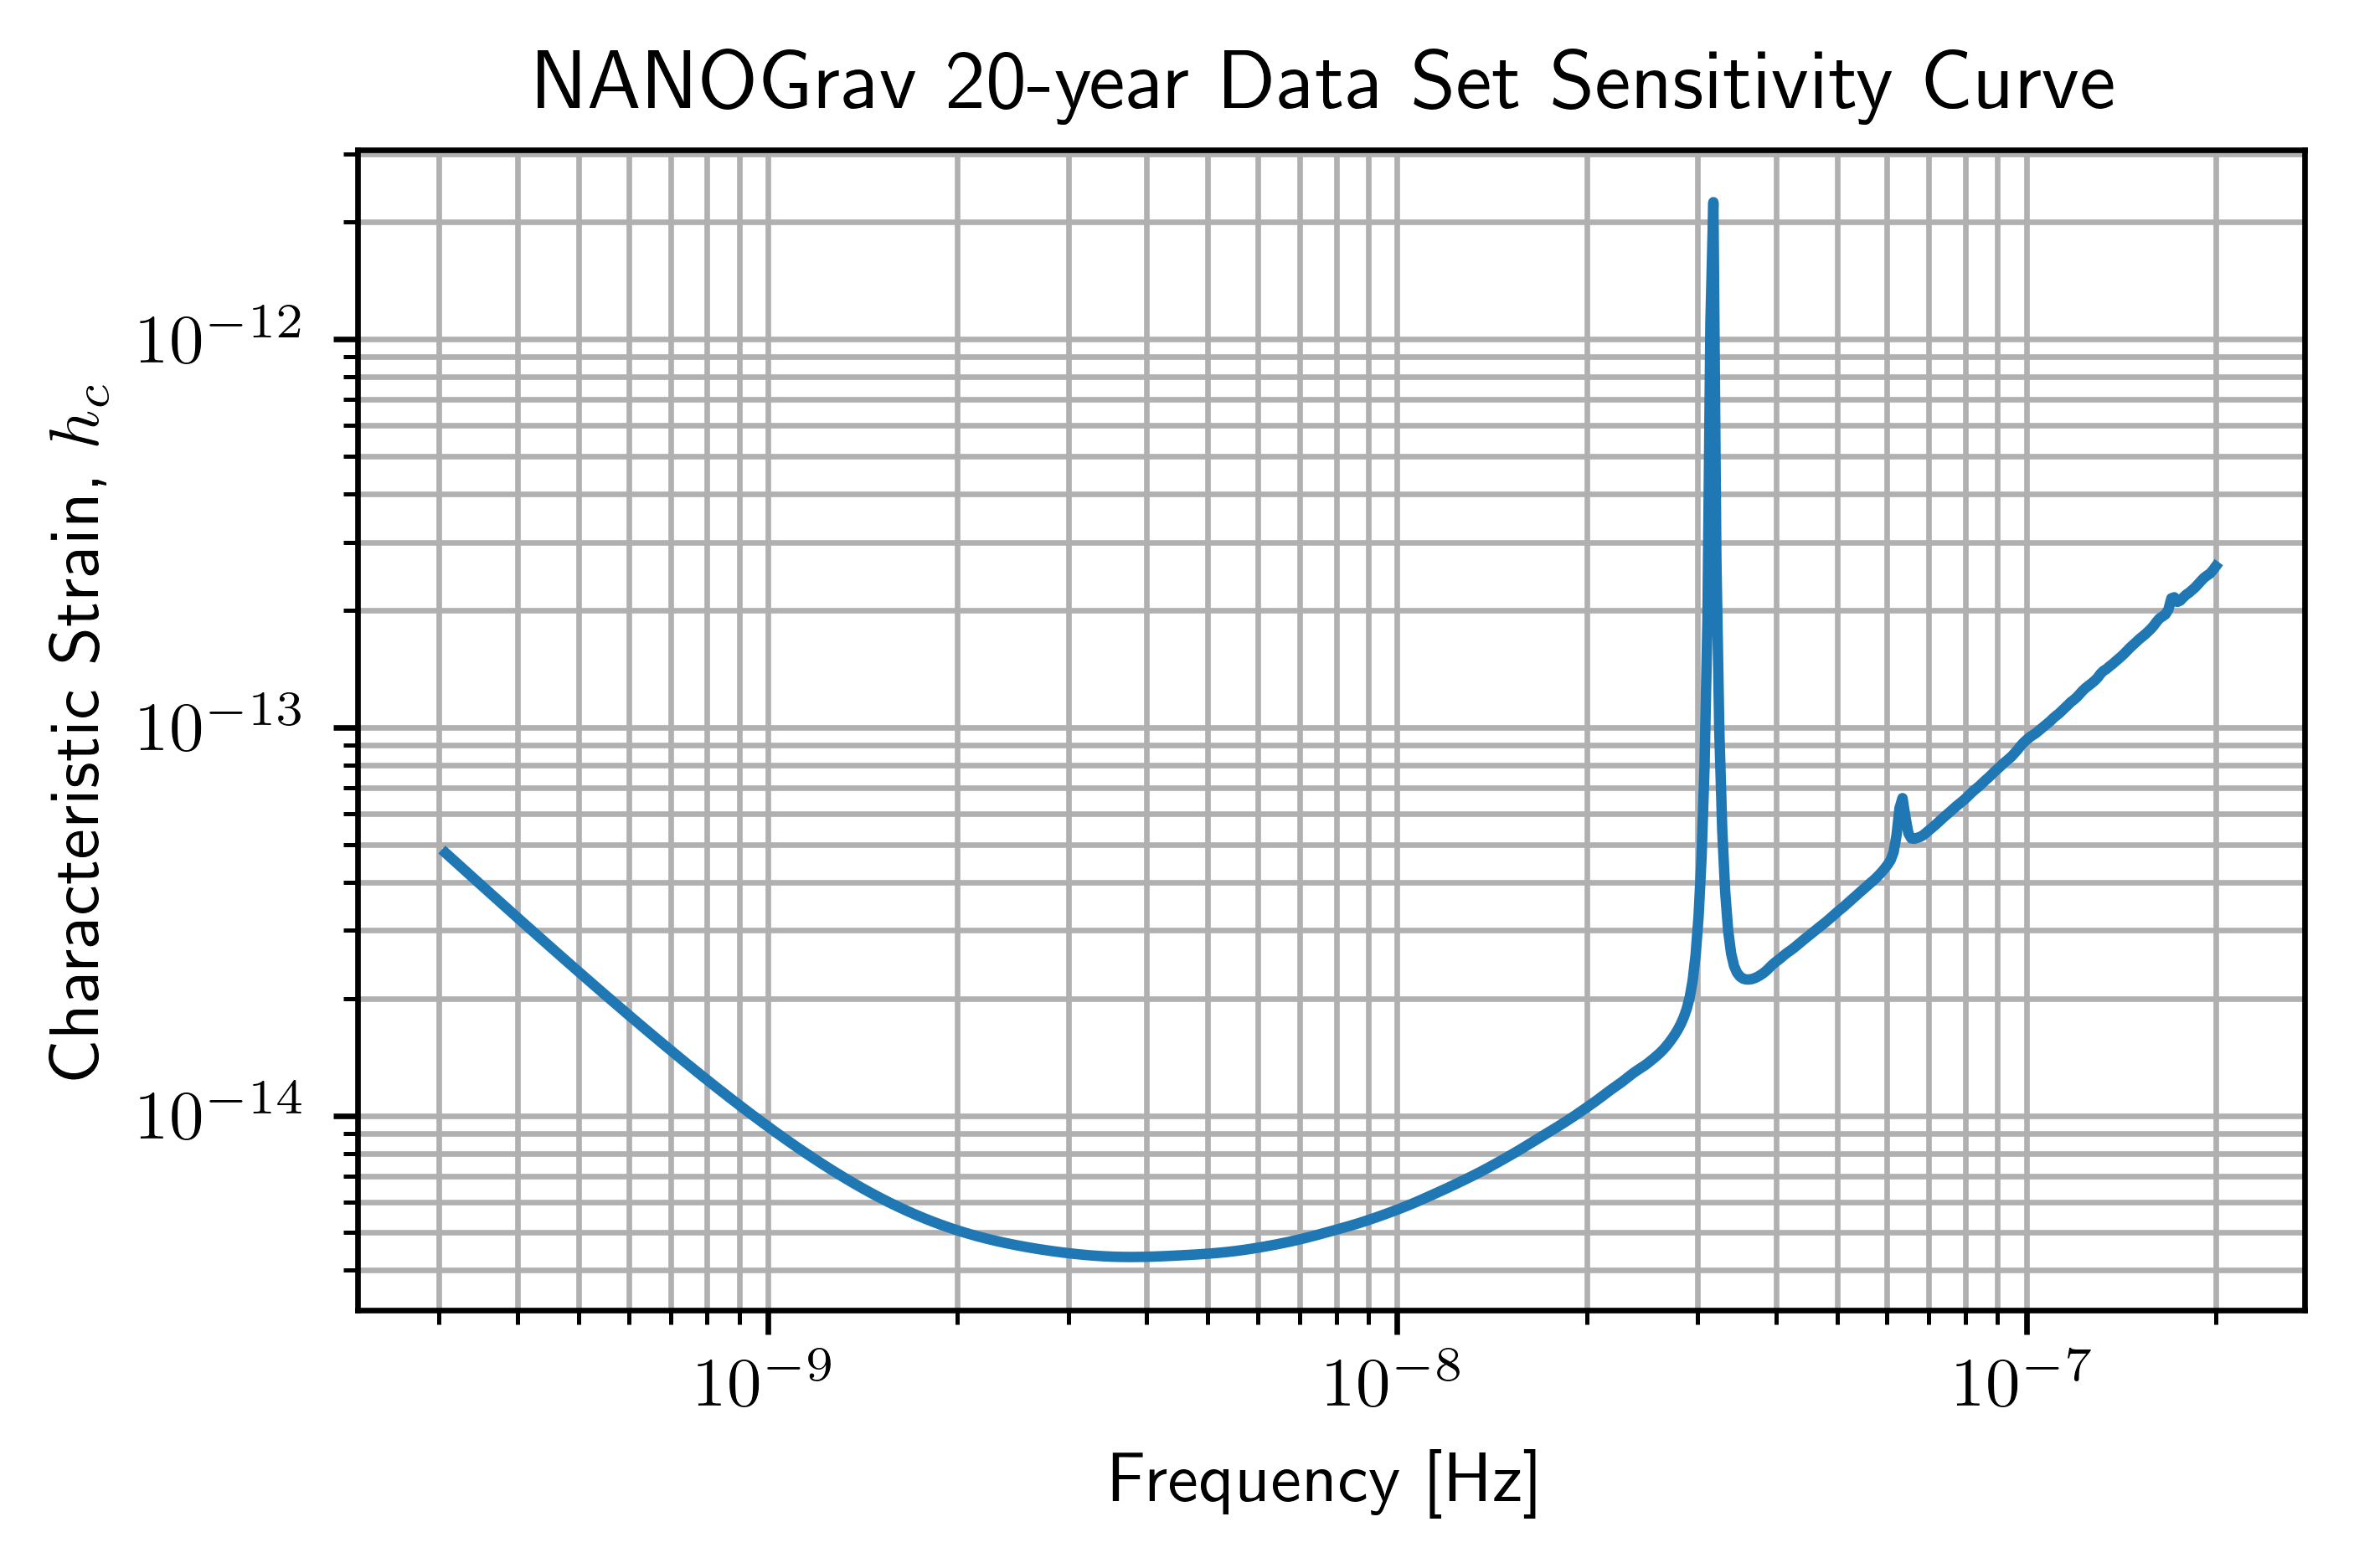

In [112]:
plt.loglog(ng20_sarah_nihans_wn.freqs,ng20_sarah_nihans_wn.h_c)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Characteristic Strain, $h_c$')
plt.title('NANOGrav 20-year Data Set Sensitivity Curve')
plt.grid(which='both')
# plt.ylim(1e-15,9e-12)
plt.show()

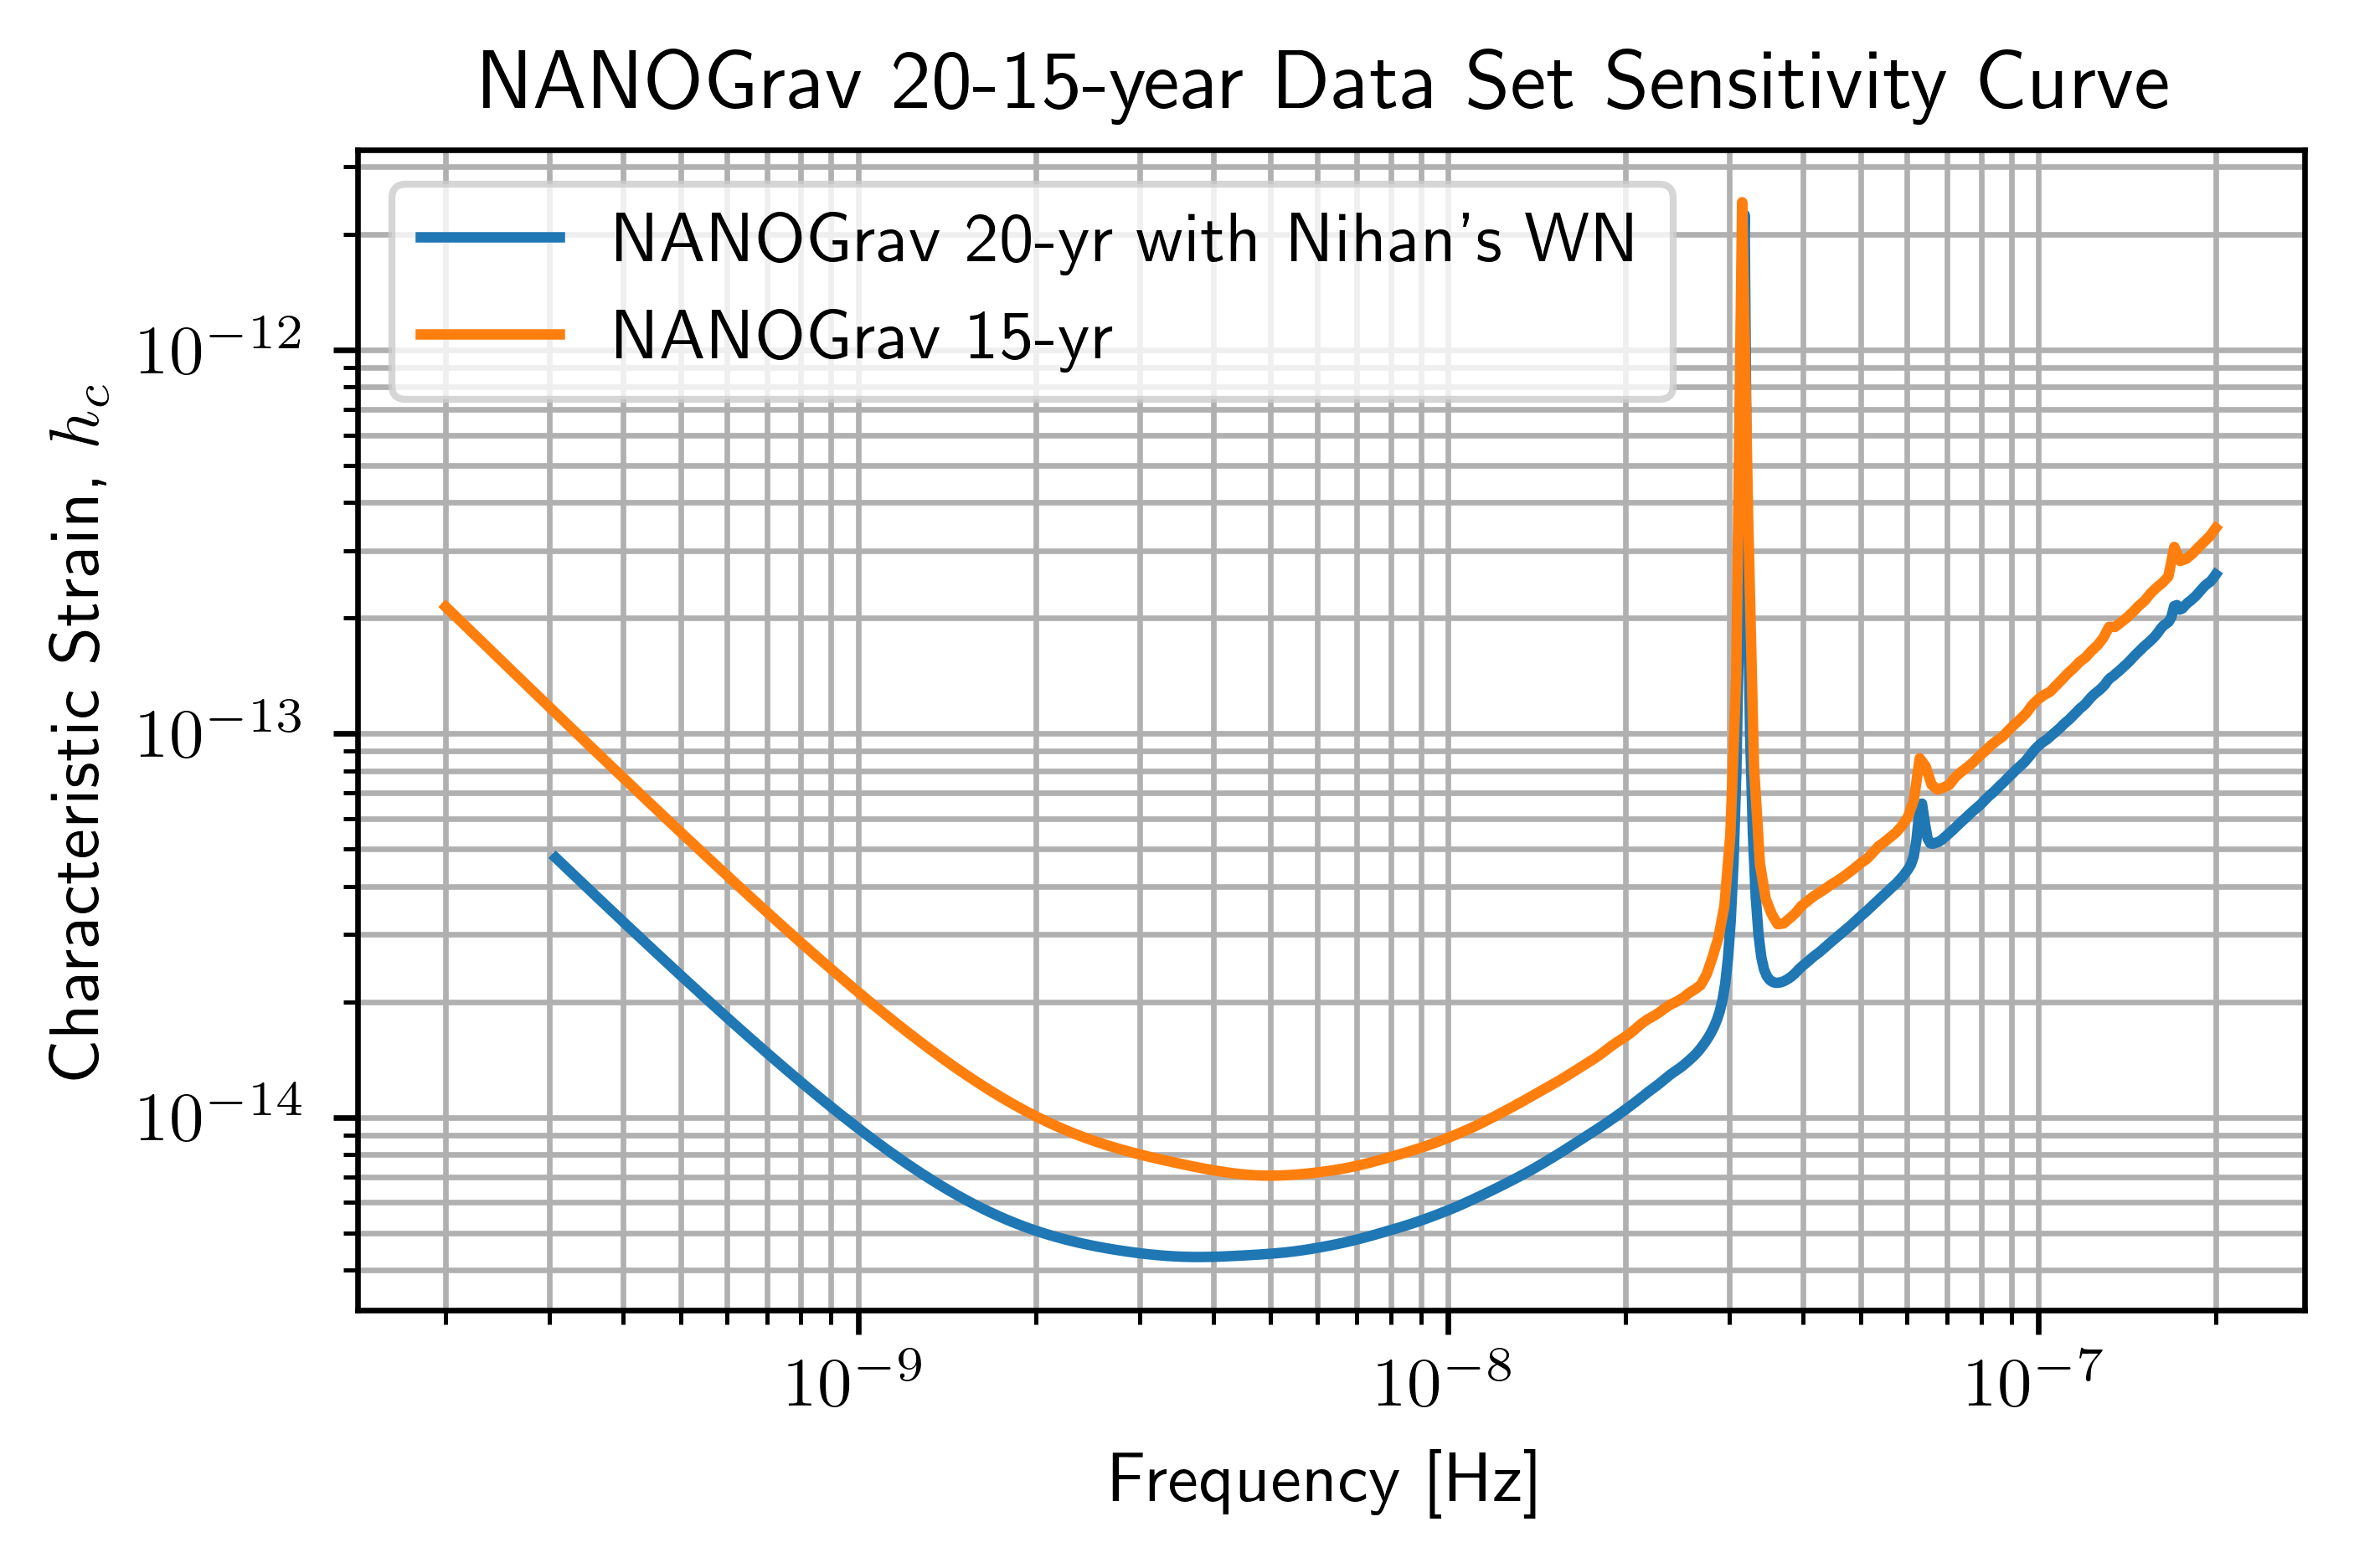

In [116]:
ng15_pkl_gwb = '/Users/ashokan/osu/sarahspta/ng15yr_v1p1_pint_logf_m2a_red_noise_vg_gwbsc.has' 
with open (ng15_pkl_gwb,'rb') as f:
    ng15_sc_gwb = pickle.load(f)

plt.loglog(ng20_sarah_nihans_wn.freqs,ng20_sarah_nihans_wn.h_c,label='NANOGrav 20-yr with Nihan\'s WN')
plt.loglog(ng15_sc_gwb.freqs,ng15_sc_gwb.h_c,label='NANOGrav 15-yr')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Characteristic Strain, $h_c$')
plt.title('NANOGrav 20-15-year Data Set Sensitivity Curve')
plt.grid(which='both')
# plt.ylim(1e-15,9e-12)
plt.legend()
plt.show()

In [117]:
def get_sliced_spectra(psrs, 
                       start_mjd=1,
                       end_mjd = None,
                       ):
    """
    Parameters 
    ----------
    
    psrs : list of enterprise.Pulsar or list of hasasia.Pulsar objects
        List of enterprise/hasasia Pulsar objects
        
    cutoff : float
        MJD cutoff for the calculation
    
    sigma_correction : ?
        ???
    """
    psrs_cut = []
    psrs_copy = copy.deepcopy(psrs)
    for idx, psr in enumerate(psrs_copy):
        # filter the data around to the appropriate slice
        #print("N_toa = ", len(psr.toas))
        psr.filter_data(start_time=start_mjd, end_time=end_mjd)
        #print("after filter = ", len(psr.toas)) 
        # If there are no TOAs remaining, or the time span of the pulsar is <3 cut.
        if (psr.toas.size == 0) or (hsen.get_Tspan([psr]) < 3*365.25*24*3600):
    #         idxs.append(idx)
            pass
        else:
            psrs_cut.append(psr)
    timespan = hsen.get_Tspan(psrs_cut)
    spectra = []
    for idx, p in enumerate(psrs_cut):
        sp = hsen.Spectrum(p, freqs=freqs,amp_gw=None, gamma_gw=None)
        sp.name = p.name
        _ = sp.NcalInv
        #print(f"psr spectra {idx} is done")
        spectra.append(sp)
    print(f"PTA spectrum with {len(spectra)} psrs created.")
    return spectra

In [118]:
end_mjd = 59033
psr_spectra = get_sliced_spectra(psrs, 
                       start_mjd=1,
                       end_mjd = end_mjd,
                       )

PTA spectrum with 64 psrs created.


In [119]:
sliced_GWBSC = hsen.GWBSensitivityCurve(spectra=psr_spectra, orf='hd', autocorr=False)
A_gwb = 6.4e-15
gamma_gwb= 3.2 
alpha_gwb = (3. - gamma_gwb) / 2.
S_h = hsen.S_h(A=A_gwb, alpha=alpha_gwb, freqs=freqs)
sliced_SNR = sliced_GWBSC.SNR(S_h)

In [120]:
sliced_SNR

np.longdouble('5.995589315914723')

In [121]:
print(len(psrs))
print(len(psr_spectra))

77
64


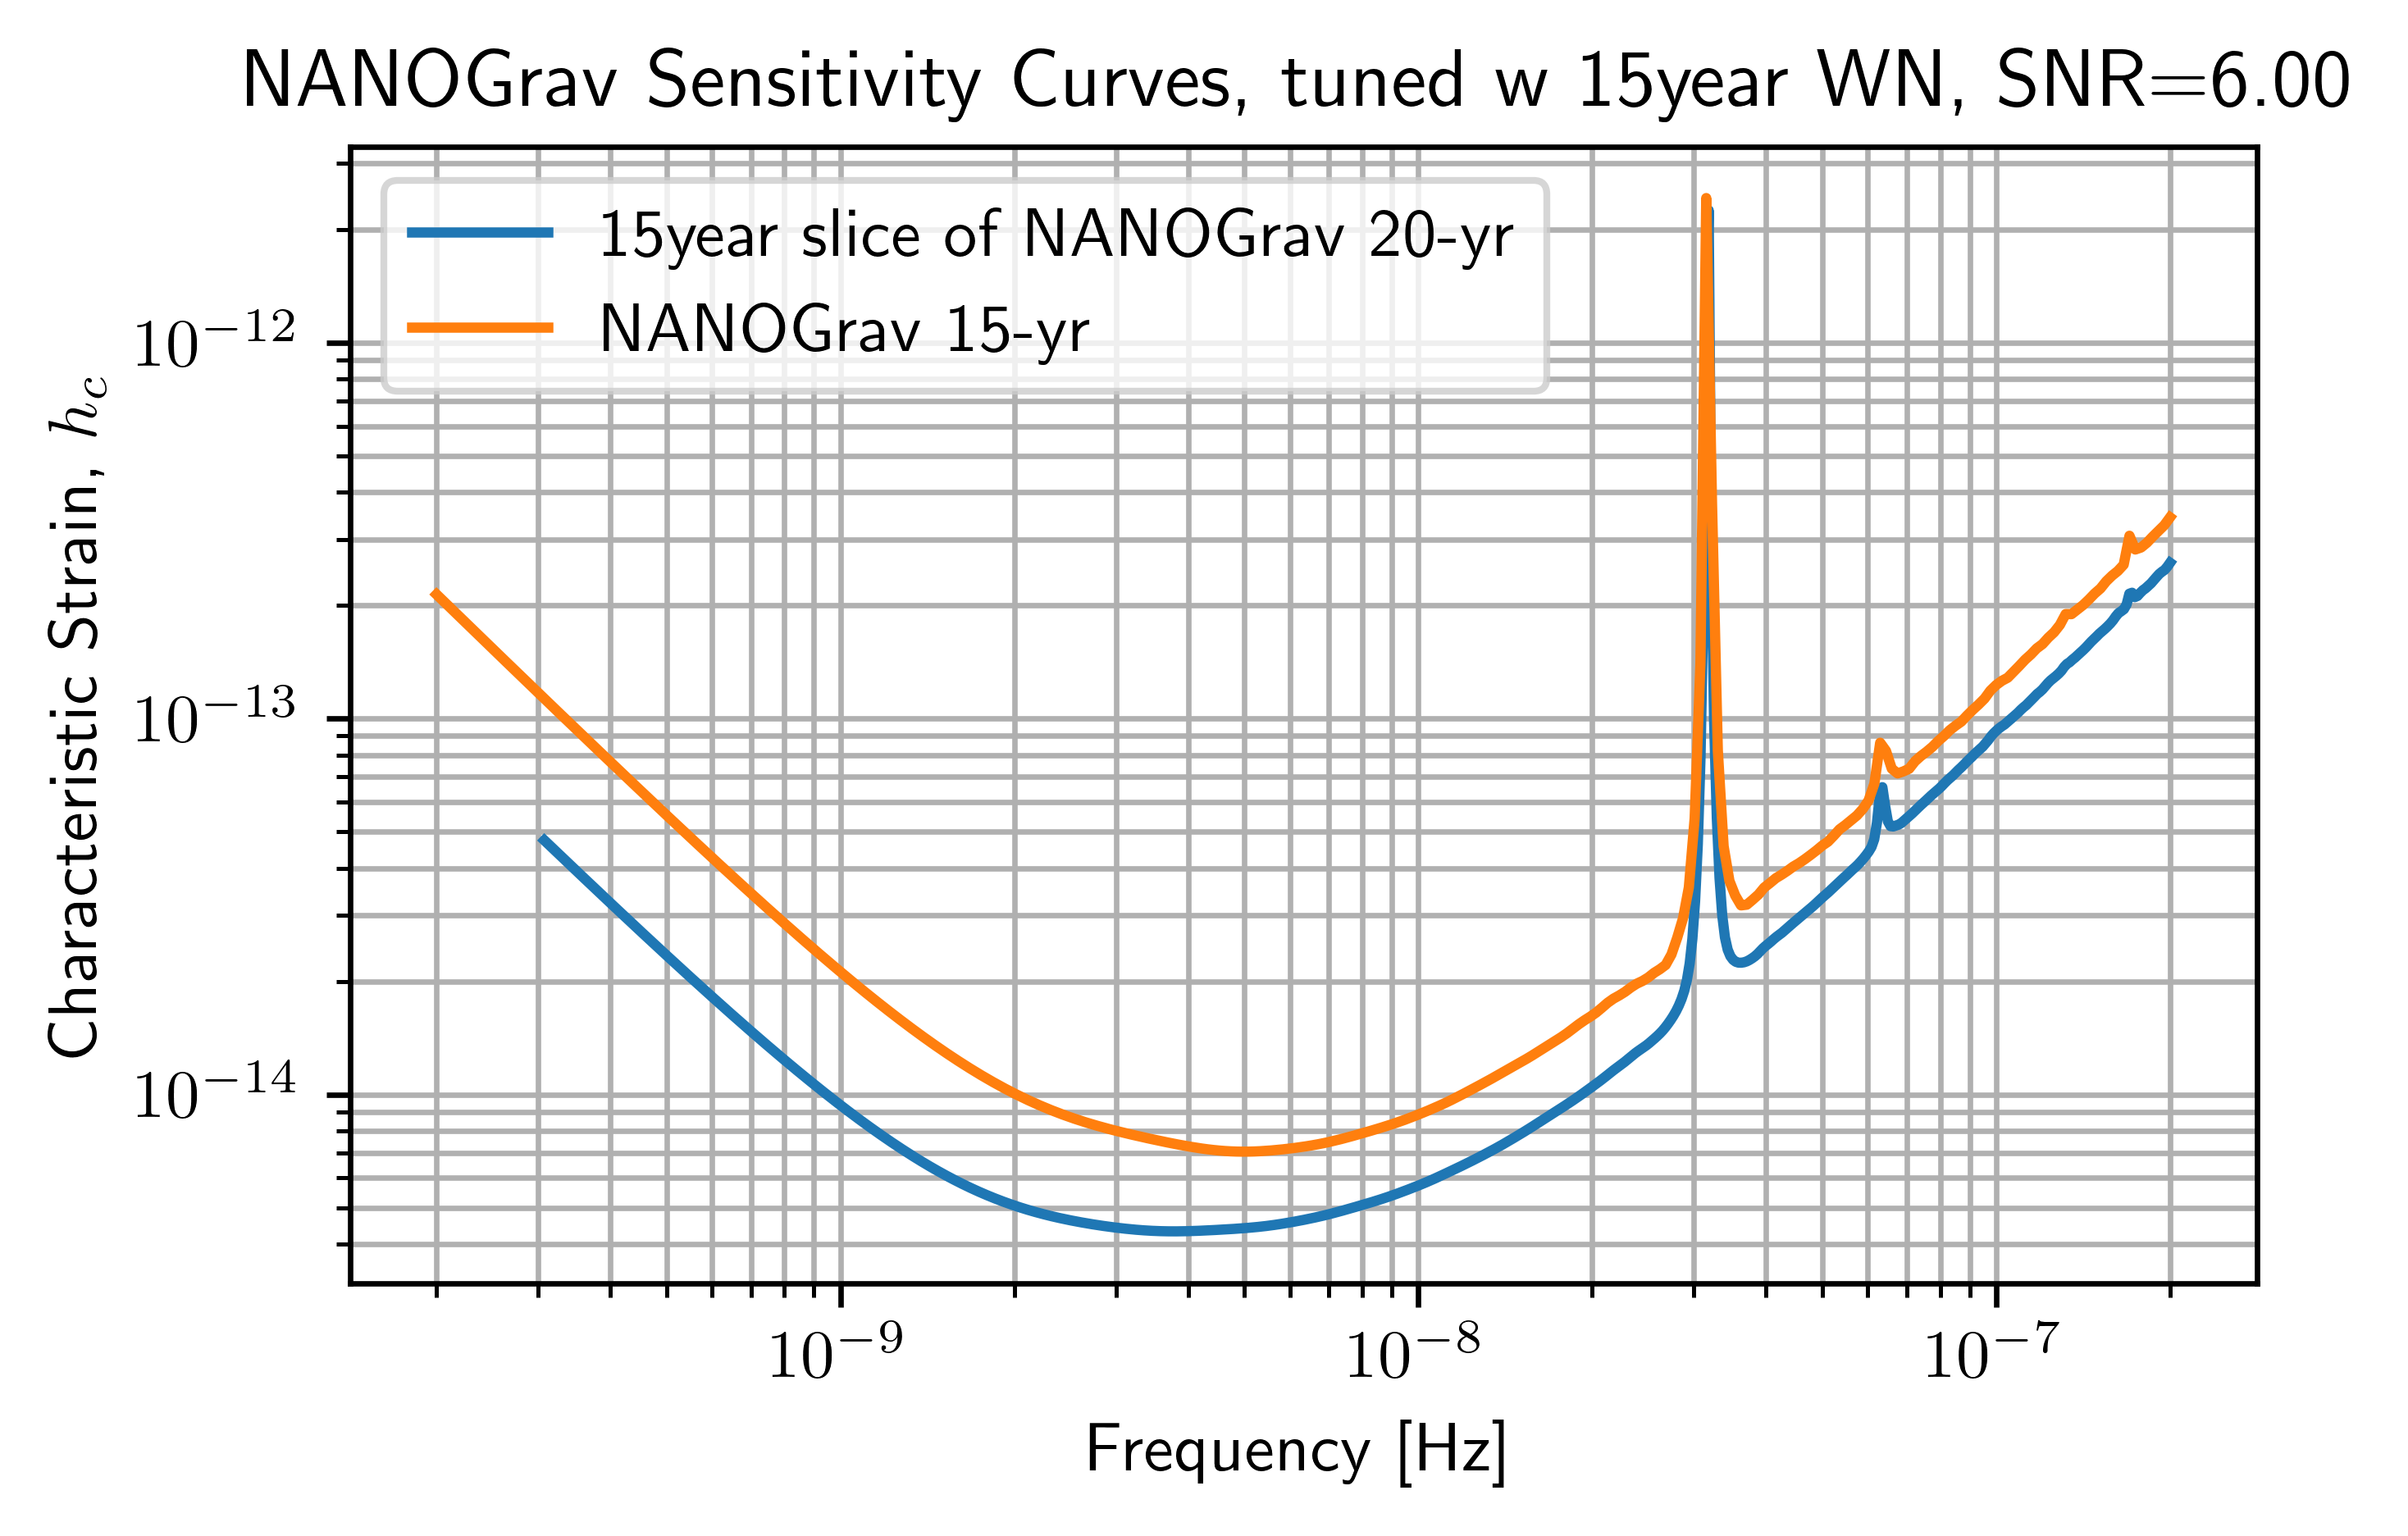

In [123]:
plt.loglog(ng20_sarah_nihans_wn.freqs,ng20_sarah_nihans_wn.h_c,label='15year slice of NANOGrav 20-yr')
plt.loglog(ng15_sc_gwb.freqs,ng15_sc_gwb.h_c,label='NANOGrav 15-yr')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Characteristic Strain, $h_c$')
plt.title(
'NANOGrav Sensitivity Curves, tuned w 15year WN, SNR={:.2f}'.format(
    sliced_SNR
)
)

#plt.title('NANOGrav Sensitivity Curves, tuned with FACTOR={:.4f}'.format(FACTOR),'SNR={:.2f}'.format(sliced_with_factor_SNR))

plt.grid(which='both')
# plt.ylim(1e-15,9e-12)
plt.legend()
plt.show()